# Parameter search for first excited state of a 1D quantum harmonic oscillator

**NOTE**: The code in this notebook takes a long time to run. Therefore, we have saved the results to files after running it once. 
You can load the results from the file directly instead of running the code again by setting the below `LOAD_FROM_FILE` variable to `True`.

In [28]:
LOAD_FROM_FILE = True

In [77]:
# Parameter search for first excited state of a 1D quantum harmonic oscillator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import numpy as np
import torch
from utils.utils import generate_input_data, skip_if
from param_search.A_train_ground_state import load_ground_state_pinn
from core.grid_search import grid_search
from core.training import train_tise
from tise1d.tise1d import PotentialHarmonicOscillator, Loss_Orthogonality, Loss_PDE, ansatzfactor_HO_sym

plt.style.use('./utils/_plot_style.mplstyle')

In [65]:
# Check for available gpu
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cpu"
print(f"Using {device} device")

Using cpu device


In [66]:
# Parameters used throughout the project
x_lim = (-5.0, 5.0)
N_samples = 256

# Generate data points
torch.manual_seed(124)
x = generate_input_data(N_samples, x_lim, device)
x_test = generate_input_data(N_samples, x_lim, device)

# Load ground state PINN to use in orthogonality loss constraint
pinn1 = load_ground_state_pinn(device)

## Random search
We first perform a random search over the following hyperparameters to get a general sense of which hyperparameters work well for this problem:
- learning rate
- learning rate energy
- ortho loss weight

The random search was performed using "Weights and Biases" (wandb). The code below shows how the random search was set up. 

```python

In [67]:
# Load data from Weights and Biases export
df = pd.read_csv("param_search/results/random_sweep_results.csv")
df["Loss_sum"] = df[["Loss_PDE", "Loss_Orthogonality"]].sum(axis=1)
df.head()

,learning_rate,learning_rate_energy,ortho_loss_weight,Loss_Orthogonality,Loss_PDE,Loss_Energy,Loss_sum
0,0.000481,0.000109,136.519395,0.015154,4.792645e-01,0.464740,0.494418
1,0.017413,0.040613,393.870226,0.010859,1.338525e+01,0.603856,13.396113
2,0.042899,0.001044,29.749248,0.998304,5.368311e-03,0.665971,1.003672
3,0.029540,0.000095,0.581123,1.000000,3.920513e-08,0.666671,1.000000
4,0.000545,0.002777,8.091688,0.013947,2.337470e-03,0.000880,0.016285


In [68]:
def plot_random_search_metrics_twinx(df: pd.DataFrame, x_axes=["learning_rate", "learning_rate_energy", "ortho_loss_weight"], metrics=["Loss_PDE", "Loss_Orthogonality"], s=2, alpha=0.1, xscale="log", yscale="log"):

    fig, axes = plt.subplots(1, len(x_axes), figsize=(6*len(x_axes), 5))
    if not hasattr(axes, "__getitem__"):
        axes = [axes]

    legend_handles = []

    for i, x_axis in enumerate(x_axes):
        base_ax = axes[i]
        base_ax.set_xscale(xscale)
        for j, metric in enumerate(metrics):
            # Legend handles
            if i == 0:
                legend_handles.append(Line2D([0], [0], marker='o', color='w', label=metric,markerfacecolor=f"C{j}", markersize=8))

            # Create twin axes
            ax = base_ax if j == 0 else base_ax.twinx()
            
            ax.set_xlabel(x_axis)

            ax.scatter(df[x_axis], df[metric], alpha=alpha, s=s, color=f"C{j}")
            ax.set_yscale(yscale)

            # --- Color ticks *and* tick marks *and* axis spine ---
            ax.tick_params(axis='y', colors=f"C{j}", which="both")  # colors tick labels + marks (if visible)

            # Ensure tick MARK LINES are colored (sometimes the above fails)
            for tickline in ax.yaxis.get_ticklines():
                tickline.set_color(f"C{j}")

            # Color the visible y-axis spine
            spine = 'left' if j == 0 else 'right'
            ax.spines[spine].set_color(f"C{j}")

        
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(metrics),
        frameon=True,
        bbox_to_anchor=(0.5, 1.0)  # adjust vertical spacing
    )

    plt.tight_layout(rect=(0, 0.0, 1, 1))  # reserve extra margin below


def plot_colormap_plot(df: pd.DataFrame, metrics=["Loss_PDE", "Loss_Orthogonality"], x="learning_rate", y="learning_rate_energy", s=20, alpha=0.5):
    fig, axes = plt.subplots(len(metrics), 1, figsize=(7, 5*len(metrics)))
    if not hasattr(axes, "__getitem__"):
        axes = [axes]
    for i, metric in enumerate(metrics):
            
        ax = axes[i]
        vmin = df[metric].min()
        if vmin <= 0:
            vmin = df[df[metric]!=0][metric].min() # LogNorm requires positive values
        log_norm = mcolors.LogNorm(vmin=vmin, vmax=df[metric].max())
        scatter = ax.scatter(df[x], df[y], alpha=alpha, s=s, c=df[metric], cmap="viridis", norm=log_norm)
        fig.colorbar(scatter, ax=ax, label=f"{metric}")
        ax.set_xscale("log")
        ax.set_yscale("log")

        if i == len(metrics)-1:
            ax.set_xlabel(x)
            ax.set_ylabel(y)
    plt.tight_layout()

def plot_3dscatter(df, params, metric, s=20, alpha=0.5):
    x, y, z = params
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        np.log10(df[x]), np.log10(df[y]), np.log10(df[z]),
        c=np.log10(df[metric]), cmap="viridis",
        s=s, alpha=alpha
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label(metric)
    return fig, ax


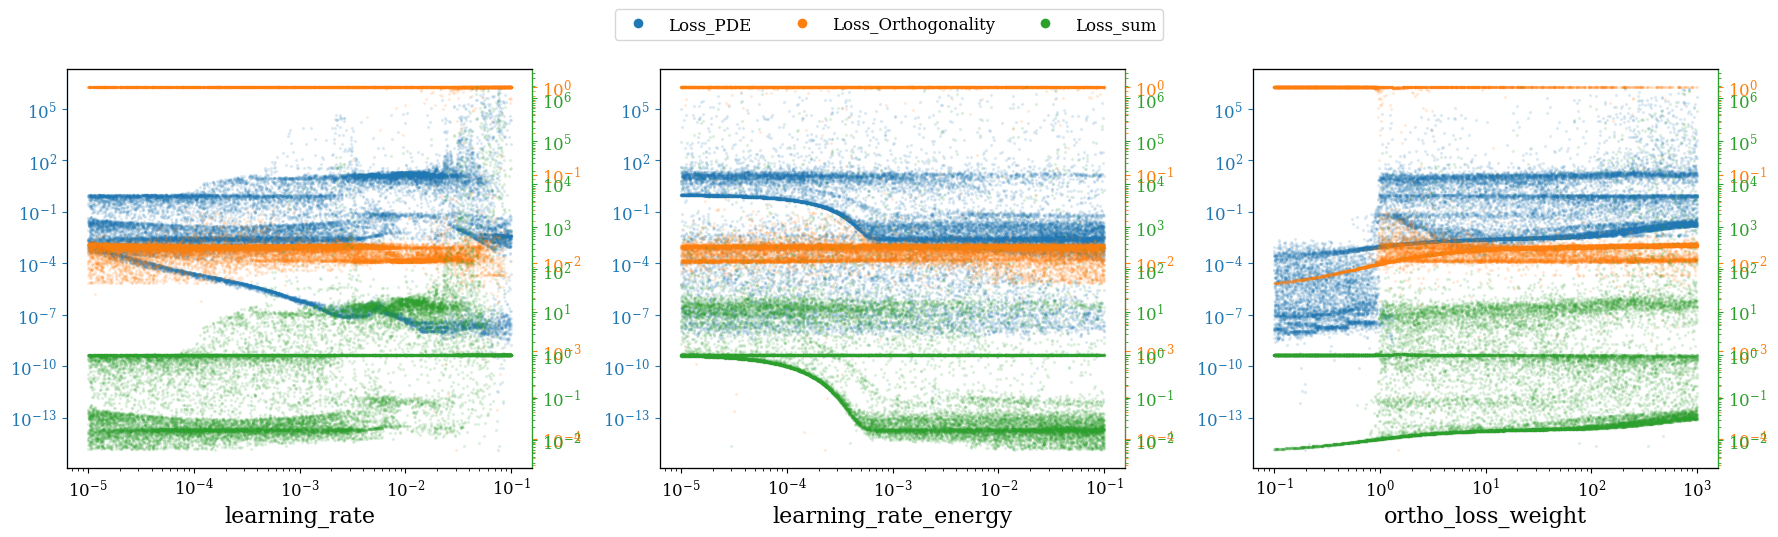

In [69]:
plot_random_search_metrics_twinx(df, metrics=["Loss_PDE", "Loss_Orthogonality", "Loss_sum"])

### Filter data
From the plots above we see that the best runs are where
- `ortho_loss_weight` <= 1.0,
and we will filter the data accordingly.

We also see patterns in `learning_rate` and `learning_rate_energy`, so we will look at these next.

In [70]:
filters = [
    df["ortho_loss_weight"] <= 1.0,
]
df2 = df.loc[pd.concat(filters, axis=1).all(axis=1)]

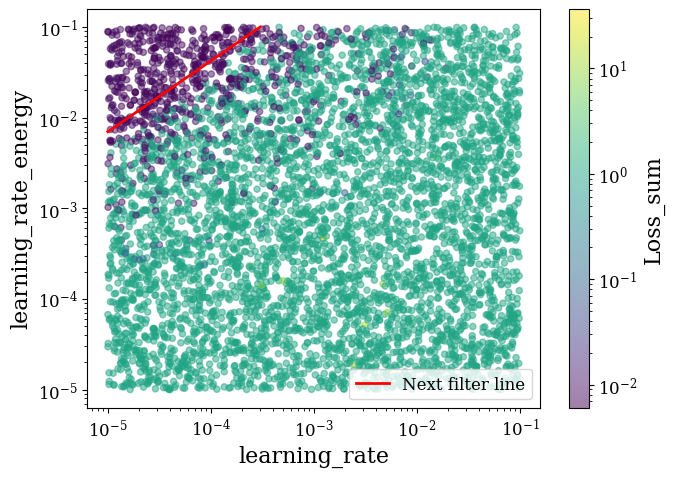

In [71]:
plot_colormap_plot(df2, metrics=["Loss_sum"])

x1,y1 = (1e-5, 7e-3)
x2,y2 = (3e-4, 1e-1)
line = [[x1, x2], [y1, y2]]
line_handle = plt.plot(line[0], line[1], color="red", label="Next filter line")

plt.legend()


plt.show()

### Filter to points above the red line

In [72]:
# Get slope and y-intercept of the line
slope = (y2-y1) / (x2-x1)
y_intercept = y1 - slope*x1

# Create filter for points above the line
filters = [
    df2["learning_rate_energy"] > slope*df2["learning_rate"]+y_intercept,
    df2["ortho_loss_weight"] < 0.4
]
df3 = df2.loc[pd.concat(filters, axis=1).all(axis=1)]

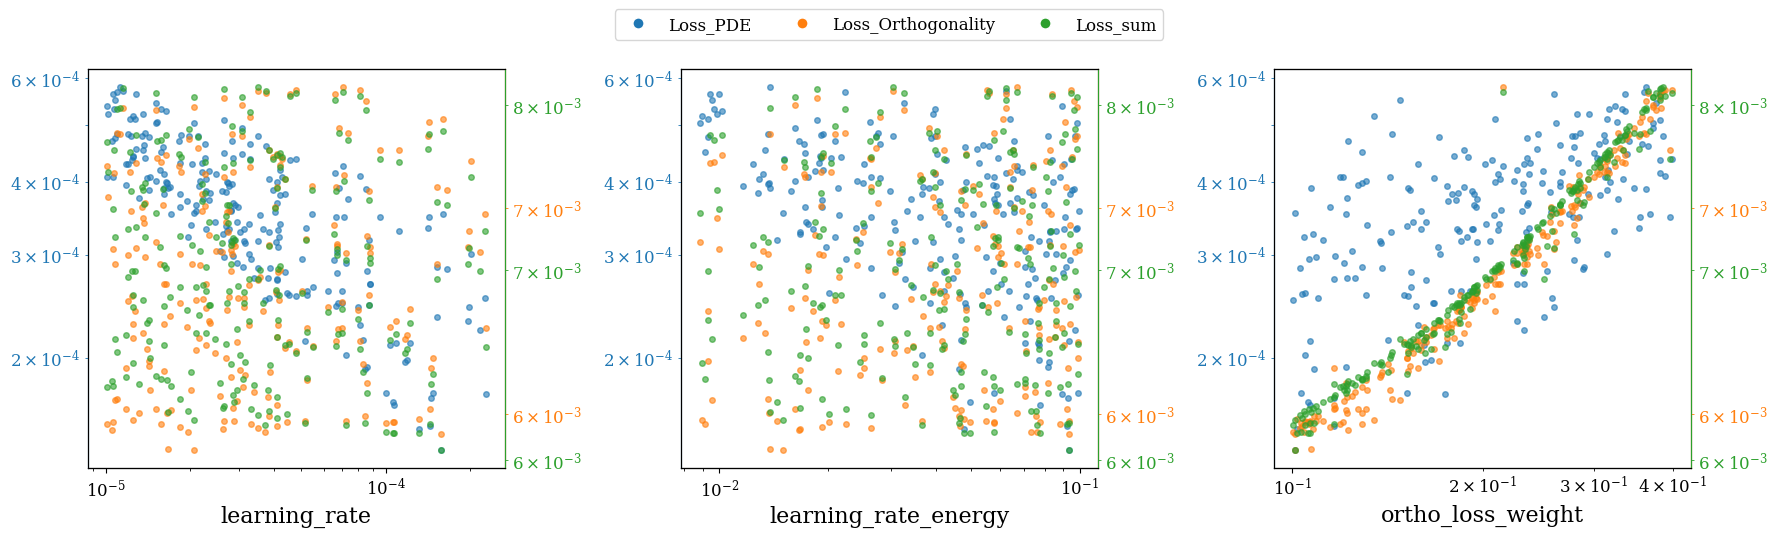

In [73]:
plot_random_search_metrics_twinx(df3, metrics=["Loss_PDE", "Loss_Orthogonality", "Loss_sum"], s=16, alpha=0.6)
plt.show()

Interestingly, the PINN gets more orthogonal to the ground state for lower `ortho_loss_weight` values in this range. We would expect the opposite, because a higher orthogonality loss weight should encourage more orthogonality.

## Further search for best `ortho_loss_weight`
The Loss_sum gets better the lower it is. We expect to see it increase again at some point, so we need to search over a new range from $[10^{-2}, 10^0]$.

We set
- `learning_rate` = $2\cdot10^{-5}$
- and `learning_rate_energy` = $2\cdot10^{-2}$,

which both are within the filter used above.

In [ ]:
ortho_loss_weight_values = np.logspace(-2, 0, 20)

def train_func(x: torch.Tensor, ortho_loss_weight: float, **kwargs):
    return train_tise(
        x,
        **kwargs,
        loss_func=Loss_PDE(PotentialHarmonicOscillator())+ortho_loss_weight*Loss_Orthogonality([pinn1]),
    )
def generate_data_func():
    return generate_input_data(256, x_lim, "cpu").numpy()

result = grid_search(
    train_func,
    metrics=[Loss_PDE(PotentialHarmonicOscillator()), Loss_Orthogonality([pinn1])],
    test_points=x_test,
    constant_parameters={
        "x_lim": x_lim,
        "ansatz_factor": ansatzfactor_HO_sym,
        "n_epochs": 3000,
        "E_init": 0.5,
        # "device": device,
        "verbose": False,

        # Guess values
        "hidden_layers": 3,
        "width": 64,
        "lr": 2e-5,
        "lr_energy": 2e-2,
    },
    sweep_parameters={
        "ortho_loss_weight": ortho_loss_weight_values,
    },
    generate_data_func=generate_data_func,
    n_repeats=5,
    seed=124,
)
